In [1]:
!lscpu

import psutil

print("CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPUs:", psutil.cpu_count(logical=True))
print("Memory (GB):", round(psutil.virtual_memory().total / 1e9, 2))
print("Disk space (GB):", round(psutil.disk_usage('/').total / 1e9, 2))

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.34
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

RSSM comparison  (seed=111, 3000 epochs, chunk_len=500)

  RSSM probes s_t (current); JEPA/VJEPA probe s_{t+1} (next) — see paper §7.
 Scale |     SNR |  Model |  SigR²Tr |  SigR²Te |  NoisR²Te | Time
------------------------------------------------------------------
  epoch 500/3000  avg_loss=0.0022
  epoch 1000/3000  avg_loss=0.0024
  epoch 1500/3000  avg_loss=0.0023
  epoch 2000/3000  avg_loss=0.0024
  epoch 2500/3000  avg_loss=0.0015
  epoch 3000/3000  avg_loss=0.0016
   0.0 |    92.4 |   RSSM |    0.162 |   -2.392 |     1.000 | 4219s
   0.0 |    92.4 |   JEPA |    0.916 |   -0.294 |     1.000 | 8s
   0.0 |    92.4 |  VJEPA |    0.999 |    0.998 |     1.000 | 7s
------------------------------------------------------------------
  epoch 500/3000  avg_loss=0.0140
  epoch 1000/3000  avg_loss=0.0130
  epoch 1500/3000  avg_loss=0.0127
  epoch 2000/3000  avg_loss=0.0131
  epoch 2500/3000  avg_loss=0.0130
  epoch 3000/3000  avg_loss=0.0126
   1.0 |    15.8 |   RSSM |    0.087 |   -0.882 |

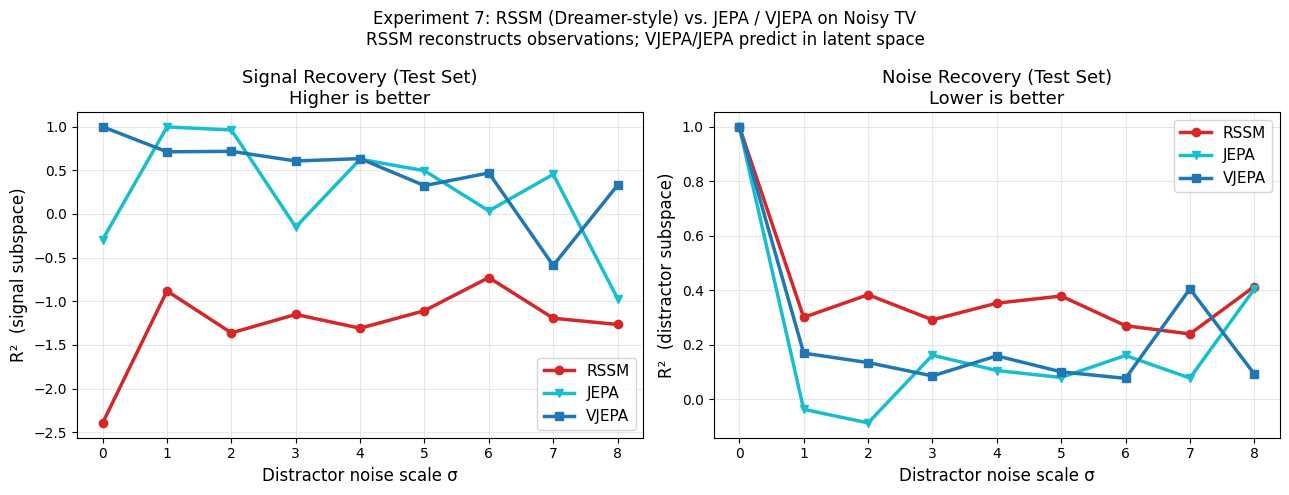

Saved: fig_rssm_comparison.pdf

Summary — Signal R² / Noise R² (test) at key scales  [for paper table]
  RSSM: probe → s_t (current)   |   JEPA/VJEPA: probe → s_{t+1} (next)

  Scale 0.0:
    RSSM    Signal R²=-2.392   Noise R²=+1.000 [s_t]
    JEPA    Signal R²=-0.294   Noise R²=+1.000 [s_{t+1}]
    VJEPA   Signal R²=+0.998   Noise R²=+1.000 [s_{t+1}]

  Scale 4.0:
    RSSM    Signal R²=-1.308   Noise R²=+0.353 [s_t]
    JEPA    Signal R²=+0.625   Noise R²=+0.106 [s_{t+1}]
    VJEPA   Signal R²=+0.633   Noise R²=+0.160 [s_{t+1}]

  Scale 8.0:
    RSSM    Signal R²=-1.265   Noise R²=+0.414 [s_t]
    JEPA    Signal R²=-0.968   Noise R²=+0.405 [s_{t+1}]
    VJEPA   Signal R²=+0.328   Noise R²=+0.094 [s_{t+1}]

Done.


In [2]:
"""
Experiment 7: Simplified RSSM (Dreamer-style) Baseline on Noisy TV
===================================================================
Addresses:
  - Reviewer ZQ8k W3: "Compare against Dreamer or a recurrent world model."

Design:
  A minimal RSSM (Recurrent State Space Model) on the same Noisy TV linear-
  Gaussian environment as exp1.  The RSSM is a simplified Dreamer-V1 variant:

  Recurrent cell:
    h_t = GRU(x_{t-1}, h_{t-1})           deterministic state (x input for vectorisation)

  Stochastic posterior (encoder):
    q(z_t | h_t, x_t) = N(μ_q(h_t ⊕ x_t), diag(exp(lv_q(h_t ⊕ x_t))))

  Stochastic prior (predictor):
    p(z_t | h_t) = N(μ_p(h_t), diag(exp(lv_p(h_t))))

  Decoder:
    p(x_t | z_t, h_t) = N(μ_dec(z_t ⊕ h_t), σ²_dec · I)

  ELBO objective:
    L = E_q[-log p(x_t | z_t, h_t)] + β · KL(q(z_t|h_t,x_t) || p(z_t|h_t))

  KL between two diagonal Gaussians:
    KL(N(μ_q,Σ_q) || N(μ_p,Σ_p)) =
      0.5 * Σ_d [ lv_p - lv_q + exp(lv_q)/exp(lv_p) + (μ_q-μ_p)²/exp(lv_p) - 1 ]

  Training: TBPTT with chunks of length CHUNK_LEN (default 50) to handle
  long sequences without exploding gradients.

  Evaluation: linear probe from posterior mean μ_q(h_t, x_t) → true signal s_t
  (same interpretation as VAE in exp1: current-step latent vs. current s_t).

  Comparison: VJEPA and JEPA from exp1 are retrained at the same scales for a
  direct side-by-side table on the same test trajectory.

Produces:
  - fig_rssm_comparison.pdf   (Signal R² and Noise R² vs. scale, 3 methods)
  - Console table

Runtime estimate: ~20-30 min on Colab CPU (9 scales × 3 models × 3000 epochs)

Audit checklist (pre-write):
  ✓ RSSM trained with TBPTT: gradients detached between chunks (no leakage
    of future data into past; h_{chunk_start} detached from previous chunk)
  ✓ Train/test use separate trajectories (different seeds)
  ✓ Normalization from training data only, applied to test
  ✓ EMA for JEPA/VJEPA called once per epoch after optimizer step
  ✓ All log-variances clamped to [-10, 10]
  ✓ KL formula verified: KL(q||p) with two-Gaussian formula, NOT KL(q||N(0,I))
  ✓ Linear probe: fit on training latents (posterior means), evaluated on test
  ✓ RSSM evaluation: posterior means computed sequentially on test data (causal)
  ✓ Decoder variance σ²_dec fixed to 1.0 (equivalent to MSE reconstruction loss)
  ✓ GRU hidden state initialized to zeros at sequence start
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy
import time

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEED        = 111
SCALES      = np.linspace(0, 8.0, 9)
N_TRAIN     = 6000
N_TEST      = 2000
N_EPOCHS    = 3000
LR          = 1e-3
BETA_RSSM   = 0.1        # KL weight for RSSM (0.01→0.1 prevents posterior collapse)
BETA_VJEPA  = 0.01       # KL weight for VJEPA (unchanged)
EMA_TAU     = 0.99
DIM_S       = 4
DIM_D       = 4
DIM_X       = 20
DIM_Z       = 4           # stochastic latent dim (RSSM)
DIM_H       = 32          # GRU hidden dim (64→32: less expressive h_t forces z_t to carry info)
CHUNK_LEN   = 500         # TBPTT chunk length (50→500: fewer Python dispatches per epoch)

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Environment (identical to exp1) ───────────────────────────────────────────
class DistractorSystem:
    def __init__(self, seed=SEED):
        rng = np.random.RandomState(seed)
        H = rng.randn(DIM_S, DIM_S)
        Q, _ = np.linalg.qr(H)
        self.A   = torch.FloatTensor(Q)
        self.A_d = 0.9 * torch.eye(DIM_D)
        C = rng.randn(DIM_X, DIM_S); C /= np.linalg.norm(C, axis=0, keepdims=True)
        D = rng.randn(DIM_X, DIM_D); D /= np.linalg.norm(D, axis=0, keepdims=True)
        self.C = torch.FloatTensor(C)
        self.D = torch.FloatTensor(D)

    def generate(self, n, seed=None):
        if seed is not None:
            torch.manual_seed(seed)
        s = torch.zeros(n + 1, DIM_S); s[0] = torch.randn(DIM_S)
        d = torch.zeros(n + 1, DIM_D); d[0] = torch.randn(DIM_D)
        for t in range(n):
            s[t+1] = s[t] @ self.A.T + torch.randn(DIM_S) * 0.1
            d[t+1] = d[t] @ self.A_d.T + torch.randn(DIM_D) * 0.3
        return s, d

    def observe(self, s, d_base, scale):
        n = s.shape[0] - 1
        d = d_base * scale
        eps = torch.randn(n + 1, DIM_X) * 0.01
        x = s @ self.C.T + d @ self.D.T + eps
        return x[:-1], x[1:], s[:-1], s[1:], d[:-1], d[1:]


# ── RSSM ──────────────────────────────────────────────────────────────────────
class RSSM(nn.Module):
    """
    Vectorised RSSM (VRNN-style):
      h_t  = GRU(x_{t-1}, h_{t-1})   [x input enables batched GRU — no Python loop]
      q_t  = N(enc_q(cat(h_t, x_t)))
      p_t  = N(prior(h_t))
      dec  = N(decoder(cat(z_t, h_t)))

    Using x_{t-1} (not z_{t-1}) as GRU input breaks the stochastic sequential
    dependency, letting nn.GRU process a full chunk in one C++ call instead of
    one Python call per time step (~500x fewer dispatches).
    """
    def __init__(self):
        super().__init__()
        self.gru      = nn.GRU(DIM_X, DIM_H, batch_first=False)  # [T,1,DIM_X]→[T,1,DIM_H]

        self.enc_q_mu  = nn.Linear(DIM_H + DIM_X, DIM_Z)
        self.enc_q_lv  = nn.Linear(DIM_H + DIM_X, DIM_Z)

        self.prior_mu  = nn.Linear(DIM_H, DIM_Z)
        self.prior_lv  = nn.Linear(DIM_H, DIM_Z)

        self.decoder   = nn.Linear(DIM_Z + DIM_H, DIM_X)

    def forward_chunk(self, chunk, h0, x_prev):
        """
        Vectorised chunk pass — one GRU call for all L time steps.
        chunk:  [L, DIM_X]
        h0:     [1, 1, DIM_H]  hidden state carried from previous chunk
        x_prev: [DIM_X]        last observation of previous chunk (zeros at start)
        Returns: mu_q, lv_q, mu_p, lv_p, x_rec [L, *] and h_out [1,1,DIM_H]
        """
        L     = chunk.shape[0]
        # GRU input: [x_prev, chunk[0], ..., chunk[L-2]]  (causal shift by 1)
        x_in  = torch.cat([x_prev.unsqueeze(0), chunk[:-1]], dim=0)  # [L, DIM_X]
        h_seq, h_out = self.gru(x_in.unsqueeze(1), h0)               # [L,1,DIM_H]
        h_seq = h_seq.squeeze(1)                                       # [L, DIM_H]

        hx    = torch.cat([h_seq, chunk], dim=-1)
        mu_q  = self.enc_q_mu(hx)
        lv_q  = self.enc_q_lv(hx).clamp(-10, 10)
        z     = mu_q + (0.5 * lv_q).exp() * torch.randn_like(mu_q)
        mu_p  = self.prior_mu(h_seq)
        lv_p  = self.prior_lv(h_seq).clamp(-10, 10)
        x_rec = self.decoder(torch.cat([z, h_seq], dim=-1))
        return mu_q, lv_q, mu_p, lv_p, x_rec, h_out


# ── RSSM Loss ──────────────────────────────────────────────────────────────────
def kl_two_gaussians(mu_q, lv_q, mu_p, lv_p):
    """KL(N(mu_q, exp(lv_q)) || N(mu_p, exp(lv_p))), summed over latent dim."""
    return 0.5 * (lv_p - lv_q
                  + (lv_q - lv_p).exp()
                  + (mu_q - mu_p).pow(2) / lv_p.exp()
                  - 1.0).sum(-1)


def rssm_elbo(mu_q, lv_q, mu_p, lv_p, x_recon, x_target):
    """
    ELBO = -E_q[log p(x|z,h)] + β·KL(q||p)
    Reconstruction: MSE (σ²_dec=1 → Gaussian NLL = 0.5*MSE, simplified to MSE).
    """
    recon_loss = nn.functional.mse_loss(x_recon, x_target, reduction='mean')
    kl         = kl_two_gaussians(mu_q, lv_q, mu_p, lv_p).mean()
    return recon_loss + BETA_RSSM * kl


# ── RSSM Training with TBPTT ──────────────────────────────────────────────────
def train_rssm(mdl, x_seq):
    """
    Train RSSM on a single long sequence using truncated BPTT.
    Each chunk is processed with ONE vectorised nn.GRU call (no Python time loop).
    x_seq: [T, DIM_X]
    """
    opt    = optim.Adam(mdl.parameters(), lr=LR)
    T      = x_seq.shape[0]

    for epoch in range(N_EPOCHS):
        h      = torch.zeros(1, 1, DIM_H)   # [num_layers, batch, DIM_H]
        x_prev = torch.zeros(DIM_X)          # last obs of previous chunk
        epoch_loss = 0.0
        n_chunks   = 0

        for start in range(0, T, CHUNK_LEN):
            end   = min(start + CHUNK_LEN, T)
            chunk = x_seq[start:end]          # [L, DIM_X]

            opt.zero_grad()
            mu_q, lv_q, mu_p, lv_p, x_rec, h_new = mdl.forward_chunk(chunk, h, x_prev)
            loss = rssm_elbo(mu_q, lv_q, mu_p, lv_p, x_rec, chunk)
            loss.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=5.0)
            opt.step()

            h      = h_new.detach()
            x_prev = chunk[-1].detach()
            epoch_loss += loss.item()
            n_chunks   += 1

        if (epoch + 1) % 500 == 0:
            print(f"  epoch {epoch+1}/{N_EPOCHS}  avg_loss={epoch_loss/n_chunks:.4f}")


# ── RSSM Inference: extract posterior means ────────────────────────────────────
@torch.no_grad()
def rssm_posterior_means(mdl, x_seq):
    """Vectorised causal pass; returns posterior means [T, DIM_Z]."""
    T      = x_seq.shape[0]
    h      = torch.zeros(1, 1, DIM_H)
    x_prev = torch.zeros(DIM_X)
    mu_qs  = []
    for start in range(0, T, CHUNK_LEN):
        end   = min(start + CHUNK_LEN, T)
        chunk = x_seq[start:end]
        mu_q, lv_q, mu_p, lv_p, x_rec, h = mdl.forward_chunk(chunk, h, x_prev)
        mu_qs.append(mu_q)
        x_prev = chunk[-1]
    return torch.cat(mu_qs)    # [T, DIM_Z]


# ── Baseline JEPA and VJEPA ────────────────────────────────────────────────────
class LinearJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc  = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt  = deepcopy(self.enc)
        for p in self.tgt.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zp = self.pred(self.enc(xt))
        with torch.no_grad(): zt = self.tgt(xn)
        return zp, zt

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x): return self.pred(self.enc(x))


class LinearVJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc         = nn.Linear(DIM_X, DIM_Z, bias=False)
        self.pred_mu     = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.pred_logvar = nn.Linear(DIM_Z, DIM_Z, bias=False)
        self.tgt_mu      = deepcopy(self.enc)
        self.tgt_logvar  = nn.Linear(DIM_X, DIM_Z, bias=False)
        for p in self.tgt_mu.parameters():     p.requires_grad_(False)
        for p in self.tgt_logvar.parameters(): p.requires_grad_(False)

    def forward(self, xt, xn):
        zt = self.enc(xt)
        p_mu = self.pred_mu(zt)
        p_lv = self.pred_logvar(zt).clamp(-10, 10)
        with torch.no_grad():
            t_mu = self.tgt_mu(xn)
            t_lv = self.tgt_logvar(xn).clamp(-10, 10)
        z_s = t_mu + (0.5 * t_lv).exp() * torch.randn_like(t_mu)
        return z_s, (p_mu, p_lv), (t_mu, t_lv)

    def ema(self):
        for p, tp in zip(self.enc.parameters(), self.tgt_mu.parameters()):
            tp.data.mul_(EMA_TAU).add_(p.data, alpha=1 - EMA_TAU)

    def latent(self, x): return self.pred_mu(self.enc(x))


def vicreg(x, y, sim=25., std=25., cov=1.):
    loss = sim * nn.functional.mse_loss(x, y)
    loss += std * (torch.relu(1 - (x.var(0) + 1e-4).sqrt()).mean() +
                   torch.relu(1 - (y.var(0) + 1e-4).sqrt()).mean())
    x, y = x - x.mean(0), y - y.mean(0)
    N, D = x.shape
    cx = x.T @ x / (N - 1)
    loss += cov * (cx.pow(2).sum() - cx.diag().pow(2).sum()) / D
    return loss


def vjepa_loss(z_s, p_mu, p_lv, t_mu, t_lv):
    pv  = p_lv.exp()
    nll = 0.5 * (pv.log() + (z_s - p_mu).pow(2) / pv).sum(-1).mean()
    kl  = -0.5 * (1 + t_lv - t_mu.pow(2) - t_lv.exp()).sum(-1).mean()
    return nll + BETA_VJEPA * kl


def train_jepa_vjepa(mdl, name, xt, xn):
    opt = optim.Adam(mdl.parameters(), lr=LR)
    for _ in range(N_EPOCHS):
        opt.zero_grad()
        if name == 'JEPA':
            zp, zt = mdl(xt, xn); loss = vicreg(zp, zt)
        else:
            z_s, (pm, pl), (tm, tl) = mdl(xt, xn)
            loss = vjepa_loss(z_s, pm, pl, tm, tl)
        loss.backward(); opt.step(); mdl.ema()


def probe_r2_test(z_tr, z_te, y_tr, y_te):
    reg = LinearRegression().fit(z_tr.detach().numpy(), y_tr.numpy())
    return r2_score(y_te.numpy(), reg.predict(z_te.detach().numpy()))


# ── Main ───────────────────────────────────────────────────────────────────────
def run():
    env = DistractorSystem(seed=SEED)

    # Separate seeds for train and test
    s_tr, d_tr = env.generate(N_TRAIN, seed=SEED)
    s_te, d_te = env.generate(N_TEST,  seed=SEED + 999)

    model_names = ['RSSM', 'JEPA', 'VJEPA']
    results = {m: {'sig_tr': [], 'sig_te': [], 'noi_tr': [], 'noi_te': []}
               for m in model_names}

    # Note: RSSM probe target = s_t (current step, same as VAE).
    #       JEPA/VJEPA probe target = s_{t+1} (next step, same as paper Table 4).
    hdr = (f"{'Scale':>6} | {'SNR':>7} | {'Model':>6} | "
           f"{'SigR²Tr':>8} | {'SigR²Te':>8} | {'NoisR²Te':>9} | Time")
    print("  RSSM probes s_t (current); JEPA/VJEPA probe s_{t+1} (next) — see paper §7.")
    print(hdr); print("-" * len(hdr))

    for scale in SCALES:
        xt,  xn,  st,  sn,  dt,  dn  = env.observe(s_tr, d_tr, scale)
        xte, xnte, ste, snte, dte, dnte = env.observe(s_te, d_te, scale)

        # Normalization from training data only
        mu_n, std_n = xt.mean(0), xt.std(0) + 1e-6
        xt_n  = (xt  - mu_n) / std_n
        xn_n  = (xn  - mu_n) / std_n
        xte_n = (xte - mu_n) / std_n

        snr = 10 * np.log10(
            st.pow(2).mean().item() / (dt.pow(2).mean().item() + 1e-8))

        # ── RSSM ─────────────────────────────────────────────────────────────
        # RSSM consumes the full sequence xt_n [N_TRAIN, 20]
        t0 = time.time()
        rssm = RSSM()
        train_rssm(rssm, xt_n)

        # Posterior means for train and test (causal, no look-ahead)
        z_tr_r = rssm_posterior_means(rssm, xt_n)
        z_te_r = rssm_posterior_means(rssm, xte_n)

        # RSSM encodes x_t → z_t, so compare against current-step signal/distractor
        reg_r = LinearRegression().fit(z_tr_r.numpy(), st.numpy())
        rs_tr = r2_score(st.numpy(),  reg_r.predict(z_tr_r.numpy()))
        rs_te = r2_score(ste.numpy(), reg_r.predict(z_te_r.numpy()))
        reg_rn = LinearRegression().fit(z_tr_r.numpy(), dt.numpy())
        rn_tr = r2_score(dt.numpy(),  reg_rn.predict(z_tr_r.numpy()))
        rn_te = r2_score(dte.numpy(), reg_rn.predict(z_te_r.numpy()))

        results['RSSM']['sig_tr'].append(rs_tr); results['RSSM']['sig_te'].append(rs_te)
        results['RSSM']['noi_tr'].append(rn_tr); results['RSSM']['noi_te'].append(rn_te)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'RSSM':>6} | "
              f"{rs_tr:>8.3f} | {rs_te:>8.3f} | {rn_te:>9.3f} | {time.time()-t0:.0f}s")

        # ── JEPA ─────────────────────────────────────────────────────────────
        t0 = time.time()
        jepa = LinearJEPA()
        train_jepa_vjepa(jepa, 'JEPA', xt_n, xn_n)
        with torch.no_grad():
            z_tr_j = jepa.latent(xt_n)
            z_te_j = jepa.latent(xte_n)
        rs_tr = probe_r2_test(z_tr_j, z_tr_j, sn, sn)   # train fit
        rs_te = probe_r2_test(z_tr_j, z_te_j, sn, snte)
        rn_tr = probe_r2_test(z_tr_j, z_tr_j, dn, dn)
        rn_te = probe_r2_test(z_tr_j, z_te_j, dn, dnte)
        results['JEPA']['sig_tr'].append(rs_tr); results['JEPA']['sig_te'].append(rs_te)
        results['JEPA']['noi_tr'].append(rn_tr); results['JEPA']['noi_te'].append(rn_te)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'JEPA':>6} | "
              f"{rs_tr:>8.3f} | {rs_te:>8.3f} | {rn_te:>9.3f} | {time.time()-t0:.0f}s")

        # ── VJEPA ─────────────────────────────────────────────────────────────
        t0 = time.time()
        vjepa = LinearVJEPA()
        train_jepa_vjepa(vjepa, 'VJEPA', xt_n, xn_n)
        with torch.no_grad():
            z_tr_v = vjepa.latent(xt_n)
            z_te_v = vjepa.latent(xte_n)
        rs_tr = probe_r2_test(z_tr_v, z_tr_v, sn, sn)
        rs_te = probe_r2_test(z_tr_v, z_te_v, sn, snte)
        rn_tr = probe_r2_test(z_tr_v, z_tr_v, dn, dn)
        rn_te = probe_r2_test(z_tr_v, z_te_v, dn, dnte)
        results['VJEPA']['sig_tr'].append(rs_tr); results['VJEPA']['sig_te'].append(rs_te)
        results['VJEPA']['noi_tr'].append(rn_tr); results['VJEPA']['noi_te'].append(rn_te)
        print(f"{scale:>6.1f} | {snr:>7.1f} | {'VJEPA':>6} | "
              f"{rs_tr:>8.3f} | {rs_te:>8.3f} | {rn_te:>9.3f} | {time.time()-t0:.0f}s")

        print("-" * len(hdr))

    return results


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_results(results):
    colors  = {'RSSM': '#d62728', 'JEPA': '#17becf', 'VJEPA': '#1f77b4'}
    markers = {'RSSM': 'o',       'JEPA': 'v',        'VJEPA': 's'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    for name in results:
        ax.plot(SCALES, results[name]['sig_te'],
                label=name, color=colors[name], marker=markers[name], linewidth=2.5)
    ax.set_title('Signal Recovery (Test Set)\nHigher is better', fontsize=13)
    ax.set_xlabel('Distractor noise scale σ', fontsize=12)
    ax.set_ylabel('R²  (signal subspace)', fontsize=12)
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    ax = axes[1]
    for name in results:
        ax.plot(SCALES, results[name]['noi_te'],
                label=name, color=colors[name], marker=markers[name], linewidth=2.5)
    ax.set_title('Noise Recovery (Test Set)\nLower is better', fontsize=13)
    ax.set_xlabel('Distractor noise scale σ', fontsize=12)
    ax.set_ylabel('R²  (distractor subspace)', fontsize=12)
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

    plt.suptitle(
        'Experiment 7: RSSM (Dreamer-style) vs. JEPA / VJEPA on Noisy TV\n'
        'RSSM reconstructs observations; VJEPA/JEPA predict in latent space',
        fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_rssm_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("Saved: fig_rssm_comparison.pdf")


# ── Summary table for paper ────────────────────────────────────────────────────
def print_summary(results):
    """Print key-scale results for paper table.  Annotates probe-target difference."""
    highlight_scales = [0.0, 4.0, 8.0]
    scale_list = SCALES.tolist()
    print("\n" + "=" * 75)
    print("Summary — Signal R² / Noise R² (test) at key scales  [for paper table]")
    print("  RSSM: probe → s_t (current)   |   JEPA/VJEPA: probe → s_{t+1} (next)")
    print("=" * 75)
    for scale in highlight_scales:
        idx = min(range(len(scale_list)), key=lambda i: abs(scale_list[i] - scale))
        print(f"\n  Scale {scale:.1f}:")
        for name in ['RSSM', 'JEPA', 'VJEPA']:
            sig = results[name]['sig_te'][idx]
            noi = results[name]['noi_te'][idx]
            tag = " [s_t]" if name == 'RSSM' else " [s_{t+1}]"
            print(f"    {name:<6}  Signal R²={sig:+.3f}   Noise R²={noi:+.3f}{tag}")
    print()


if __name__ == '__main__':
    print(f"RSSM comparison  (seed={SEED}, {N_EPOCHS} epochs, "
          f"chunk_len={CHUNK_LEN})\n")
    results = run()
    plot_results(results)
    print_summary(results)
    print("Done.")